In [227]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
from shap.datasets import iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [228]:
#load dataset

X, y = iris(display= True)

In [229]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [230]:
y[:5]

['setosa', 'setosa', 'setosa', 'setosa', 'setosa']

In [231]:
y = pd.Series(y)

In [232]:
y[:5]

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
dtype: str

In [233]:
#split data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify=y)

In [234]:
X_train.shape

(120, 4)

In [235]:
X_test.shape

(30, 4)

In [236]:
#distribution of target
y_train.value_counts(normalize= True)


versicolor    0.333333
setosa        0.333333
virginica     0.333333
Name: proportion, dtype: float64

In [237]:
y_test.value_counts(normalize= True)

versicolor    0.333333
setosa        0.333333
virginica     0.333333
Name: proportion, dtype: float64

In [238]:
#encode the target

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


In [239]:
y_test

array([1, 1, 1, 0, 0, 1, 2, 1, 0, 2, 2, 1, 2, 1, 2, 0, 1, 0, 2, 1, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 2])

In [240]:
#fit the model in data
rf = RandomForestClassifier(n_estimators= 100, random_state= 42)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [241]:
# prediction onthe data 

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

In [242]:
accuracy_score(y_train, y_pred_train)

1.0

In [243]:
accuracy_score(y_test, y_pred_test)

0.9666666666666667

POST HOC 

In [244]:
#make an explainer

explainer = shap.TreeExplainer(
    model= rf,
    data = X_train,
    model_output= "probability" 
)

In [245]:
#base value
explainer.expected_value

array([0.3598, 0.2988, 0.3414])

In [246]:
le.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [247]:
# calculate base value manually

rf.predict_proba(X_train).mean(axis=0)

array([0.33325, 0.33425, 0.3325 ])

In [248]:
test_case = X_test.iloc[0: 1, :]
test_case

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
99,5.7,2.8,4.1,1.3


In [249]:
#prediction for test data

prediction = rf.predict(test_case)

prediction_prob = rf.predict_proba(test_case)

In [250]:
prediction

array([1])

In [251]:
le.inverse_transform(prediction)

array(['versicolor'], dtype=object)

In [252]:
prediction_prob

array([[0., 1., 0.]])

In [253]:
#calculate the shapely values

shap_values = explainer(test_case)

In [254]:
shap_values

.values =
array([[[-0.00886667,  0.02486667, -0.016     ],
        [-0.01036667,  0.0045    ,  0.00586667],
        [-0.16531666,  0.36718332, -0.20186666],
        [-0.17525   ,  0.30274999, -0.1275    ]]])

.base_values =
array([[0.3598, 0.2988, 0.3414]])

.data =
array([[5.7, 2.8, 4.1, 1.3]])

In [255]:
shap_values.base_values

array([[0.3598, 0.2988, 0.3414]])

In [256]:
explainer.expected_value

array([0.3598, 0.2988, 0.3414])

In [257]:
shap_values.data

array([[5.7, 2.8, 4.1, 1.3]])

In [258]:
test_case

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
99,5.7,2.8,4.1,1.3


In [259]:
shap_values.shape

(1, 4, 3)

1 -> no of rows
4 -> no of features
3 -> no of classes 

In [260]:
shap_values.values

array([[[-0.00886667,  0.02486667, -0.016     ],
        [-0.01036667,  0.0045    ,  0.00586667],
        [-0.16531666,  0.36718332, -0.20186666],
        [-0.17525   ,  0.30274999, -0.1275    ]]])

In [261]:
shap_values[0,:,0]

.values =
array([-0.00886667, -0.01036667, -0.16531666, -0.17525   ])

.base_values =
np.float64(0.3598000000000001)

.data =
array([5.7, 2.8, 4.1, 1.3])

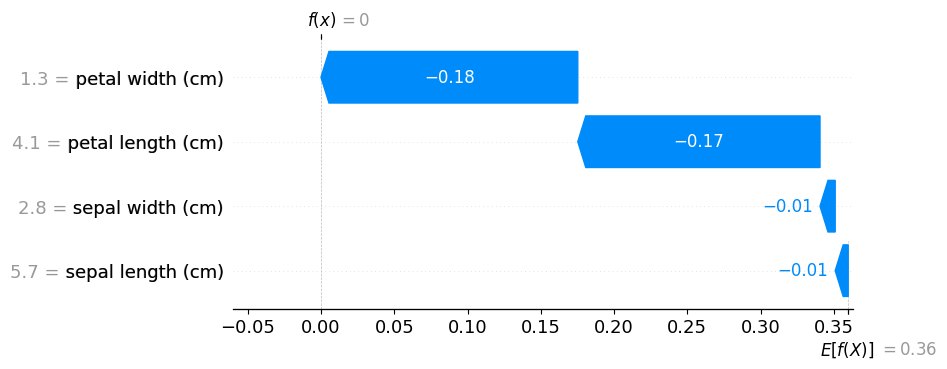

In [262]:
#waterfall plot
shap.waterfall_plot(shap_values[0,:,0])

In [263]:
# check additivity

shap_values[0,:,0].values.sum()

np.float64(-0.35979999202769253)

In [264]:
(shap_values[0,:,0].base_values + shap_values[0,:,0].values.sum()).round()

np.float64(0.0)

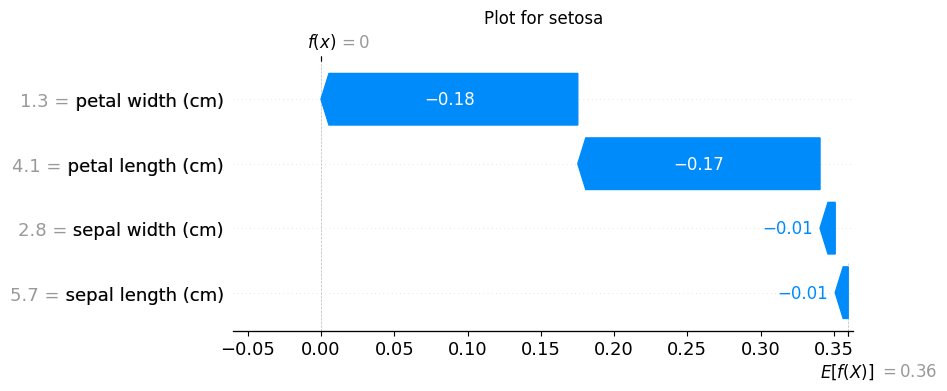

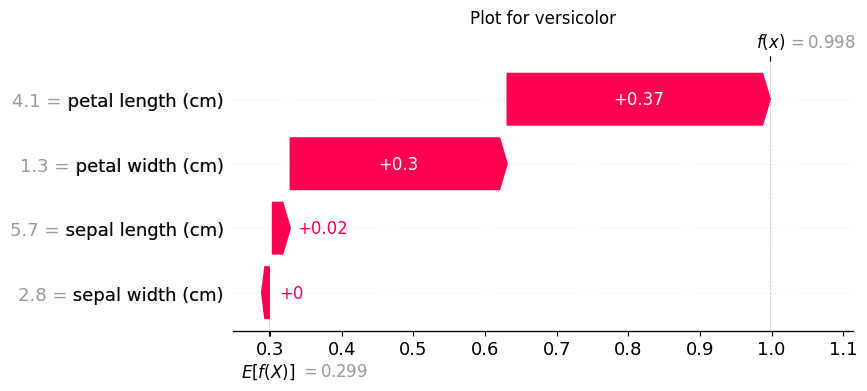

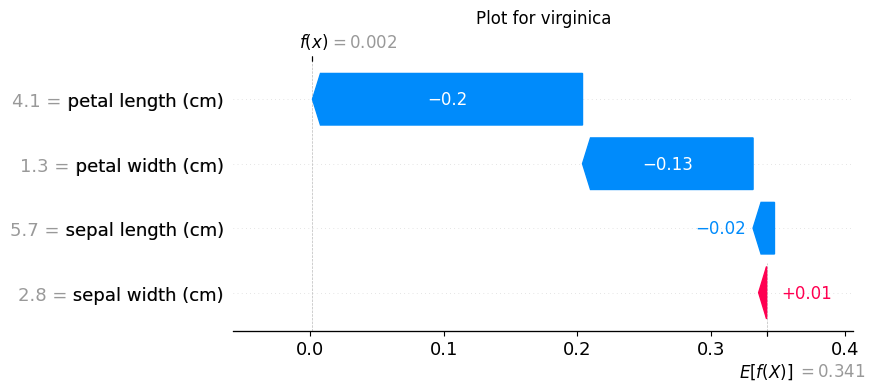

In [265]:
for i in range(len(le.classes_)):
    plt.title(f"Plot for {le.classes_[i]}")
    shap.waterfall_plot(shap_values[0,:,i])
    print("\n\n")
    

In [266]:
shap_values[0,:,2].values.sum()

np.float64(-0.3394999924453441)